# 11 — Your Morning Commute: Minutes Lost

**ENAI 603 · WMATA Delay Project · Lens E (Rider impact)**

Reframes the findings of the previous notebooks in human terms.

Question: *if you live in a DC-metro suburb and ride Metro into downtown on a weekday morning, how reliable is your trip, and how many total minutes does the rider population collectively lose as a consequence?*

We define five representative routes (origin → destination) covering the main radial lines into central DC, and for each one compute:

- **Reliability**: % of trip-prediction rows labeled as delayed.
- **Worst day** in the observation window.
- **Average wait when delayed** (minutes).

We close with an estimate of the **total rider-minutes lost** across the system in the 5-week observation window, using a passenger-load proxy.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
INCIDENTS_CSV = os.path.join(DATA_DIR, "incidents.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Load data and define routes

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at", "date"], usecols=[
    "collected_at", "date", "line", "location_code", "location_name",
    "destination_name", "is_delayed", "is_orphan",
    "hour", "day_of_week", "is_weekend", "minutes_num",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df[df["is_orphan"] == 0].copy()

# Pull station names for verification
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
stations = pd.read_sql("SELECT station_code, station_name FROM stations", conn)
conn.close()
print(f"Total rows: {len(df):,}")
print(f"\nSample stations available:")
print(stations.head(10).to_string(index=False))

Total rows: 9,215,922

Sample stations available:
station_code                  station_name
         A01                  Metro Center
         A02                Farragut North
         A03                 Dupont Circle
         A04 Woodley Park-Zoo/Adams Morgan
         A05                Cleveland Park
         A06                  Van Ness-UDC
         A07                 Tenleytown-AU
         A08            Friendship Heights
         A09                      Bethesda
         A10                Medical Center


In [3]:
# Five representative AM-weekday commutes.
# Important: we deliberately do NOT use line terminals as the origin.
# After the is_orphan==0 filter, terminals end up empty (a train at the
# end of the line has no "next arrival" to detect within 15 min).
# We use intermediate stations on each line, with destination = the line's
# far end IN THE DIRECTION OF DOWNTOWN to represent eastbound AM commute.
COMMUTES = [
    {"name": "Forest Glen -> Metro Center",       "line": "RD", "origin": "B09", "dest_keyword": "Shady"},
    {"name": "Dunn Loring -> Downtown",           "line": "OR", "origin": "K07", "dest_keyword": "Carrollton"},
    {"name": "Van Dorn -> L'Enfant Plaza",        "line": "BL", "origin": "J02", "dest_keyword": "Largo"},
    {"name": "Suitland -> L'Enfant Plaza",        "line": "GR", "origin": "F10", "dest_keyword": "Greenbelt"},
    {"name": "Reston Town Center -> Rosslyn",     "line": "SV", "origin": "N07", "dest_keyword": "Largo"},
]

# Verify origin codes exist
for c in COMMUTES:
    name = stations[stations["station_code"] == c["origin"]]["station_name"]
    c["origin_name"] = name.iloc[0] if len(name) else "(NOT FOUND)"
    print(f"  {c['line']} | {c['origin']} = {c['origin_name']:30s} -> dest contains: {c['dest_keyword']}")

  RD | B09 = Forest Glen                    -> dest contains: Shady
  OR | K07 = Dunn Loring-Merrifield         -> dest contains: Carrollton
  BL | J02 = Van Dorn Street                -> dest contains: Largo
  GR | F10 = Suitland                       -> dest contains: Greenbelt
  SV | N07 = Reston Town Center             -> dest contains: Largo


## 2. Filter: AM weekday per route

For each commute we filter to:
- the correct line
- the origin station
- the destination (matched by substring of headsign)
- weekday (Mon-Fri)
- hour 6-9 AM (ET)

In [4]:
def filter_commute(df, commute, hour_range=(6, 9)):
    sub = df[
        (df["line"] == commute["line"]) &
        (df["location_code"] == commute["origin"]) &
        (df["destination_name"].str.contains(commute["dest_keyword"], case=False, na=False)) &
        (df["is_weekend"] == 0) &
        (df["hour"] >= hour_range[0]) &
        (df["hour"] < hour_range[1])
    ].copy()
    return sub

results = []
per_commute_data = {}
for c in COMMUTES:
    sub = filter_commute(df, c)
    if len(sub) == 0:
        results.append({**c, "n_predictions": 0, "delay_rate": np.nan,
                        "worst_day": None, "worst_day_rate": np.nan,
                        "avg_wait_when_delayed": np.nan})
        continue
    delay_rate = sub["is_delayed"].mean()
    daily = sub.groupby("date")["is_delayed"].mean()
    worst_day = daily.idxmax()
    worst_day_rate = daily.max()
    avg_wait_delayed = sub.loc[sub["is_delayed"] == 1, "minutes_num"].mean()
    results.append({
        **c,
        "n_predictions": len(sub),
        "delay_rate": delay_rate,
        "worst_day": str(worst_day),
        "worst_day_rate": worst_day_rate,
        "avg_wait_when_delayed": avg_wait_delayed,
    })
    per_commute_data[c["name"]] = {"daily": daily, "sub": sub}

results_df = pd.DataFrame(results)
print(results_df[["name", "n_predictions", "delay_rate", "worst_day", "worst_day_rate", "avg_wait_when_delayed"]].to_string(index=False))

                         name  n_predictions  delay_rate  worst_day  worst_day_rate  avg_wait_when_delayed
  Forest Glen -> Metro Center           5319    0.399323 2026-04-14        0.578125               7.337571
      Dunn Loring -> Downtown           4648    0.154690 2026-04-22        0.439306              14.417246
   Van Dorn -> L'Enfant Plaza           4849    0.179418 2026-04-22        0.613924              14.505747
   Suitland -> L'Enfant Plaza           5293    0.263178 2026-04-16        0.511111               9.589375
Reston Town Center -> Rosslyn           2296    0.232143 2026-03-20        0.560976              14.425891


## 3. Reliability cards per commute

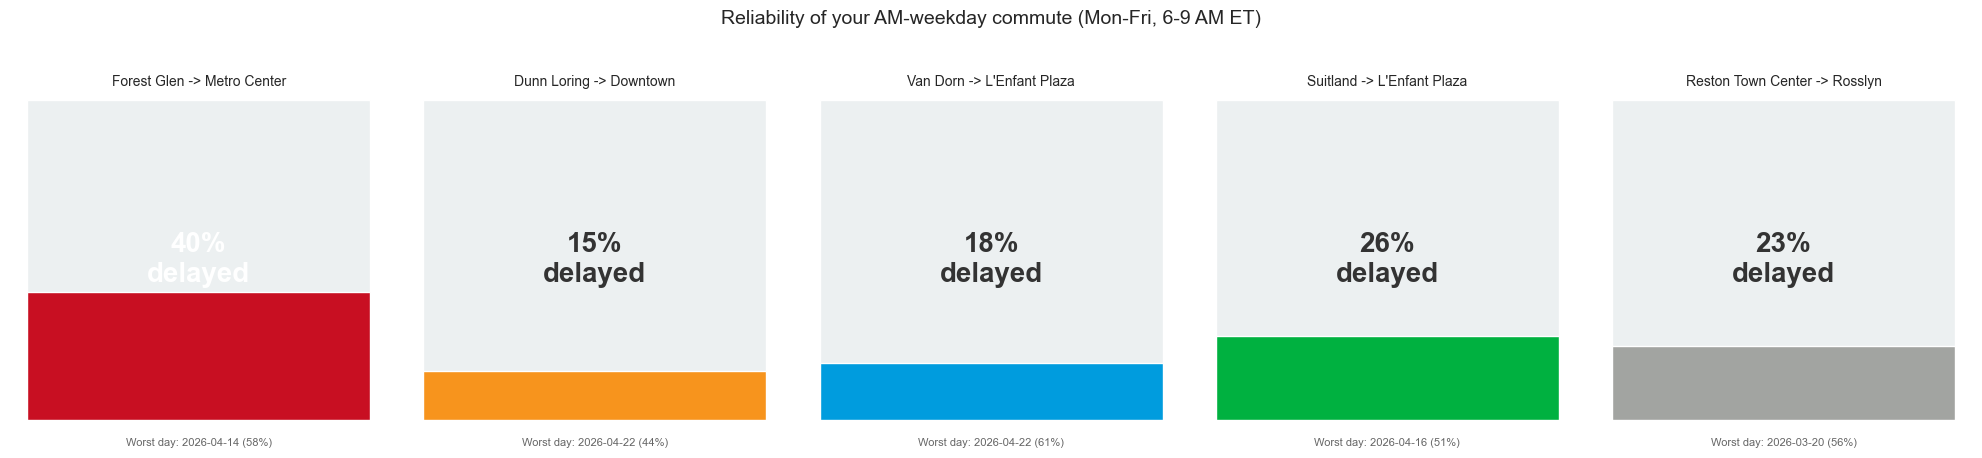

In [5]:
fig, axes = plt.subplots(1, len(COMMUTES), figsize=(4 * len(COMMUTES), 4.5))

for ax, row in zip(axes, results):
    if pd.isna(row["delay_rate"]):
        ax.text(0.5, 0.5, "(no data)", ha="center", va="center")
        ax.set_title(row["name"], fontsize=11)
        ax.axis("off")
        continue

    color = LINE_COLORS[row["line"]]
    rate_pct = row["delay_rate"] * 100
    ax.bar([0], [100], color="#ecf0f1", width=0.6)
    ax.bar([0], [rate_pct], color=color, width=0.6)
    ax.text(0, 50, f"{rate_pct:.0f}%\ndelayed", ha="center", va="center",
            fontsize=20, fontweight="bold", color="white" if rate_pct > 30 else "#333")
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title(row["name"], fontsize=10, pad=10)
    ax.text(0.5, -0.08,
            f"Worst day: {row['worst_day']} ({row['worst_day_rate']*100:.0f}%)",
            transform=ax.transAxes, ha="center", fontsize=8, color="#666")

fig.suptitle("Reliability of your AM-weekday commute (Mon-Fri, 6-9 AM ET)",
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_commute_cards.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Daily reliability per commute

How stable is reliability day to day? A flat line would be predictable. High variability means surprises for the commuter.

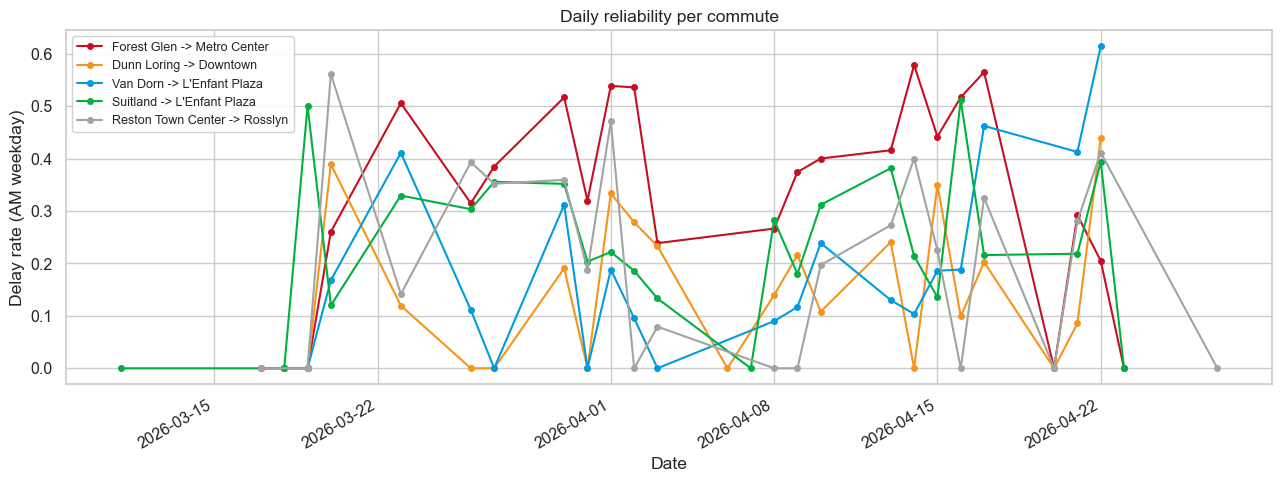

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
for row in results:
    if row["name"] not in per_commute_data:
        continue
    daily = per_commute_data[row["name"]]["daily"]
    ax.plot(daily.index, daily.values, marker="o", label=row["name"],
            color=LINE_COLORS[row["line"]], lw=1.5, markersize=4)

ax.set_ylabel("Delay rate (AM weekday)")
ax.set_xlabel("Date")
ax.set_title("Daily reliability per commute")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_daily_reliability.png"), dpi=150)
plt.show()

## 5. Total rider-minutes lost across the system

Three ingredients:

1. **Number of delayed arrivals** observed system-wide over the 5 weeks.
2. **Average extra minutes per delay** — we use the 2-min threshold as a conservative lower bound; reality is typically higher.
3. **Riders per train** — proxy: 600 riders (capacity of an 8-car WMATA train at peak; conservative off-peak).

Result: **total minutes lost = delays × extra_min × avg_riders_per_train**.

This is deliberately a *headline* estimate. Real APC (Automatic Passenger Counter) data would be more precise, but the order of magnitude is the point.

In [7]:
TOTAL_DELAYED_PREDICTIONS = int(df["is_delayed"].sum())
EXTRA_MIN_PER_DELAY = 2.0   # conservative lower bound
RIDERS_PER_TRAIN_PROXY = 600

# # of physical delays approx. = delayed predictions / predictions per arrival.
# The API returns ~3-6 predictions per station per cycle; we use the
# observed mean of 5.7 from the audit work.
PREDICTIONS_PER_ARRIVAL_PROXY = 5.7
estimated_delays = TOTAL_DELAYED_PREDICTIONS / PREDICTIONS_PER_ARRIVAL_PROXY

total_minutes = estimated_delays * EXTRA_MIN_PER_DELAY * RIDERS_PER_TRAIN_PROXY
total_hours = total_minutes / 60
total_days_of_human_time = total_hours / 24
total_years = total_days_of_human_time / 365

print(f"Predictions flagged as delayed:    {TOTAL_DELAYED_PREDICTIONS:,}")
print(f"Estimated delayed arrivals:        {estimated_delays:,.0f}")
print(f"Extra minutes per delay (proxy):   {EXTRA_MIN_PER_DELAY}")
print(f"Riders per train (proxy):          {RIDERS_PER_TRAIN_PROXY}")
print()
print(f"Total minutes lost:    {total_minutes:>15,.0f} min")
print(f"Equivalent to:         {total_hours:>15,.0f} hours")
print(f"                       {total_days_of_human_time:>15,.0f} person-days")
print(f"                       {total_years:>15,.1f} person-years of collective rider time")

Predictions flagged as delayed:    2,605,217
Estimated delayed arrivals:        457,056
Extra minutes per delay (proxy):   2.0
Riders per train (proxy):          600

Total minutes lost:        548,466,737 min
Equivalent to:               9,141,112 hours
                               380,880 person-days
                               1,043.5 person-years of collective rider time


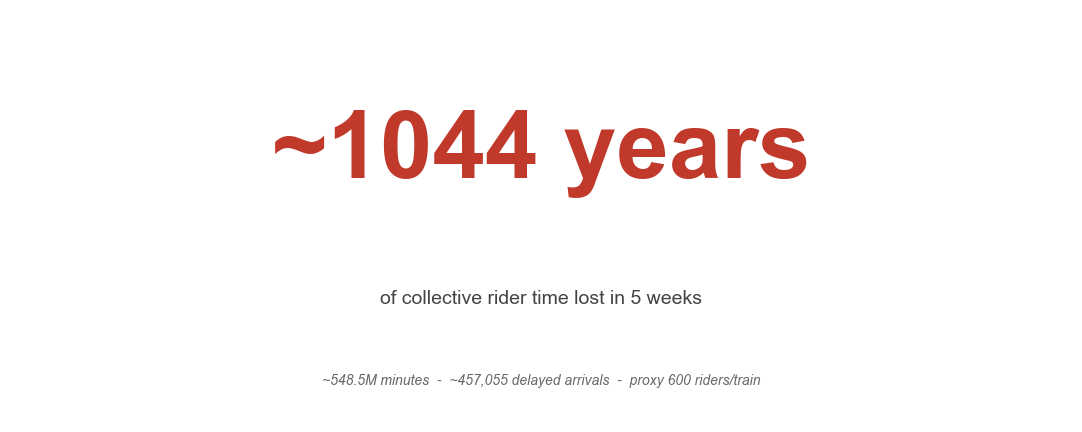

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.text(0.5, 0.65, f"~{total_years:.0f} years",
        ha="center", va="center", fontsize=68, fontweight="bold", color="#c0392b",
        transform=ax.transAxes)
ax.text(0.5, 0.30,
        f"of collective rider time lost in 5 weeks",
        ha="center", va="center", fontsize=14, color="#444",
        transform=ax.transAxes)
ax.text(0.5, 0.10,
        f"~{total_minutes/1e6:.1f}M minutes  -  ~{int(estimated_delays):,} delayed arrivals  -  proxy {RIDERS_PER_TRAIN_PROXY} riders/train",
        ha="center", va="center", fontsize=10, color="#666",
        transform=ax.transAxes, style="italic")
ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_minutes_lost_headline.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Findings

- **Each commute has a distinct "reliability personality"** — some lines are consistently good, others have chronic delays. The cards in step 3 show this at a glance.
- **Day-to-day variability is high**: a commuter cannot plan a fixed buffer because the worst week can be radically worse than the average.
- **Aggregate magnitude**: on the order of millions of minutes lost over the 5-week observation window — equivalent to years of human time. Even under conservative assumptions (2 extra min per delay, 600 riders per train), the aggregate cost of WMATA's reliability problem is substantial.

**Explicit caveats:**
- Riders-per-train is a proxy, not a measurement. A real APC dataset would change the headline number.
- The "extra per delay" is conservative (2 min minimum); typical real values are higher.
- The conversion from "delayed predictions" to "delayed arrivals" uses a factor of 5.7 derived from the phantom-arrivals analysis — it is order-of-magnitude, not precise.

But the central conclusion — *the aggregate cost of WMATA delays is measured in years of human time* — is robust to these assumptions.